In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm

from matrix_processing_helpers import sparsify_global_percentile
from matrix_processing_helpers import sparsify_topk_rows
from matrix_processing_helpers import reorder
from matrix_processing_helpers import reorder_clustering

# from models_transformer import TwoHeadTransformerNet, SingleOutTransformerNet
# from attention_rollout_helpers import (compute_attention_rollout, 
#                                        get_batch_rollout, 
#                                        compute_rollout_over_dataloader,
#                                        analyze_spectrum)

### Load

In [2]:
type_names = {"age": "age", "mets": "MetSCORE", "sex": "sex"}

results_local = np.load(f"Results_TR/attention_rollout_local/rollout_results_multi.npz")
results_global = np.load(f"Results_TR/attention_rollout_global/rollout_results_multi.npz")

with open(f"Results_TR/attention_rollout_local/attn_matrices_multi.pkl", "rb") as f:
    attn_matrices = pickle.load(f)

with open(f"Results_TR/attention_rollout_global/sorted_pairs_multi.pkl", "rb") as f:
    sorted_pairs = pickle.load(f)

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

### Rollout

In [3]:
interactions = results_global['interactions']
interactions_log = results_global['interactions_log']
importance = results_global['importance_global']
# interactions_sparse = sparsify_global_percentile(interactions, keep_diagonal=False)
# interactions_topk = sparsify_topk_rows(interactions, keep_diagonal=False)

#### Plot: top-k feature importance

In [5]:
sorted_indices = np.argsort(importance)[::-1]
sorted_features_names = [feature_names[i] for i in sorted_indices]
sorted_values = importance[sorted_indices]

df = pd.DataFrame({'metabolite': sorted_features_names, 'attn_score': sorted_values})
df.to_csv(f"Results_TR/attention_rollout_global/features_importance_multi.csv", index=False)
df

,metabolite,attn_score
0,Glucose (mM),1.321388
1,LDL cholesterol (mg/dl),1.175495
2,Urate (mg/dl),1.113927
3,Erythrocyte sedimentation rate (mm/h),1.099315
4,Glycine (mM),1.081370
...,...,...
67,Lipoprotein(a) (mg/dl),0.926607
68,Glutamine to glutamate ratio (unitless),0.923324
69,Sarcosine (mM),0.921223
70,Aspartate (mM),0.920379


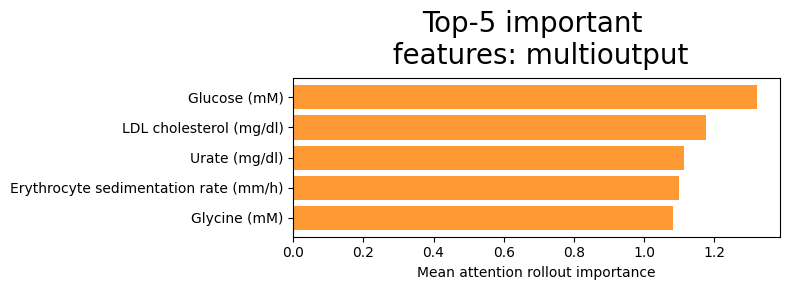

In [6]:
k = 5
top_idx = np.argsort(importance)[::-1][:k]
top_features = [feature_names[i] for i in top_idx]
top_values = importance[top_idx]

plt.figure(figsize=(8, 3))
plt.barh(range(k), top_values[::-1], color=[1, 0.6, 0.2])
plt.yticks(range(k), top_features[::-1])
plt.xlabel("Mean attention rollout importance")
plt.title(f"Top-{k} important \n features: multioutput", fontsize=20, pad=10)
plt.tight_layout()
plt.savefig(f"FiguresPaper/attention_rollout/importance_top{k}_multi.pdf", bbox_inches="tight")
plt.show()

#### Plot: top-k attention rollout

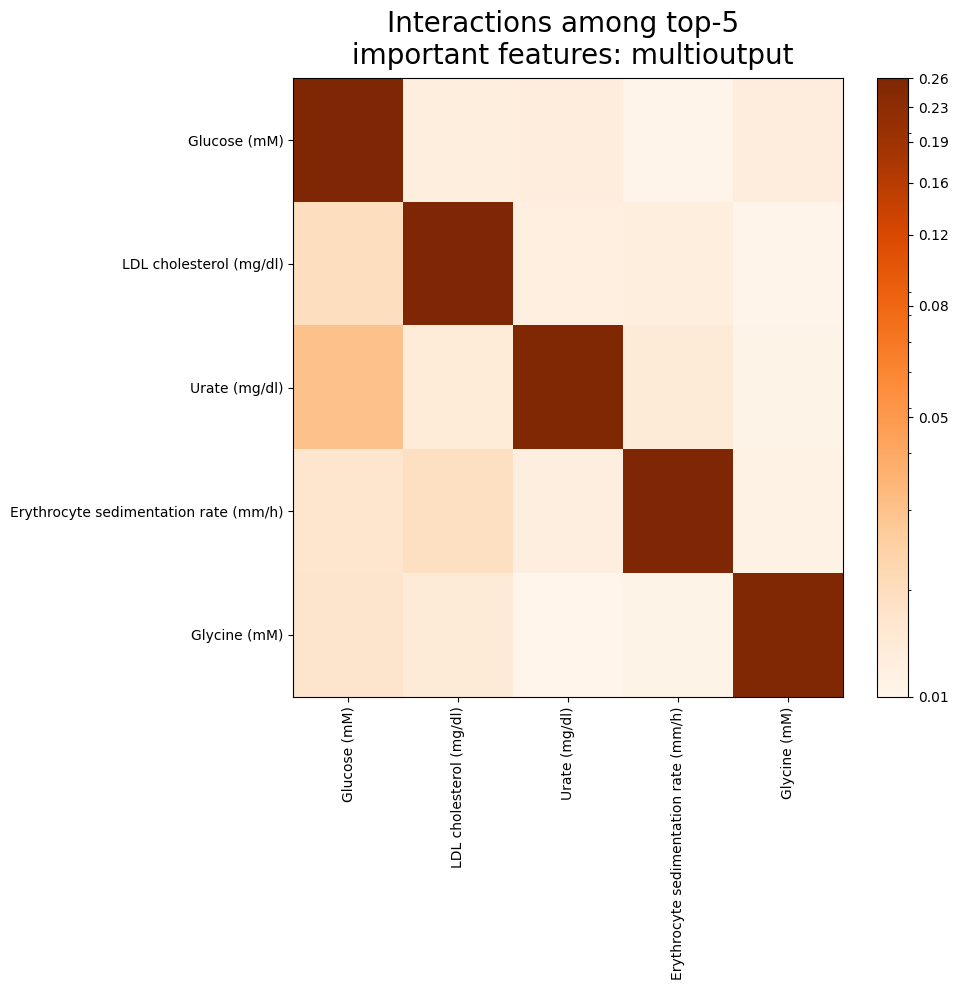

In [9]:
submatrix = interactions[np.ix_(top_idx, top_idx)]
subnames = [feature_names[i] for i in top_idx]

np.max(submatrix)

plt.figure(figsize=(10, 10))
im = plt.imshow(submatrix, aspect='auto', cmap='Oranges', 
                norm=LogNorm(vmin=np.min(submatrix), vmax=np.max(submatrix))
               )

ticks = np.linspace(np.min(submatrix), np.max(submatrix), 8)

cbar = plt.colorbar(im, ticks=ticks)

cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.xticks(range(k), subnames, rotation=90)
plt.yticks(range(k), subnames)
plt.title(f"Interactions among top-{k} \n important features: multioutput", 
          fontsize=20, pad=10)
plt.tight_layout()
plt.savefig(f"FiguresPaper/attention_rollout/interactions_top{k}_multi.pdf", bbox_inches="tight")
plt.show()

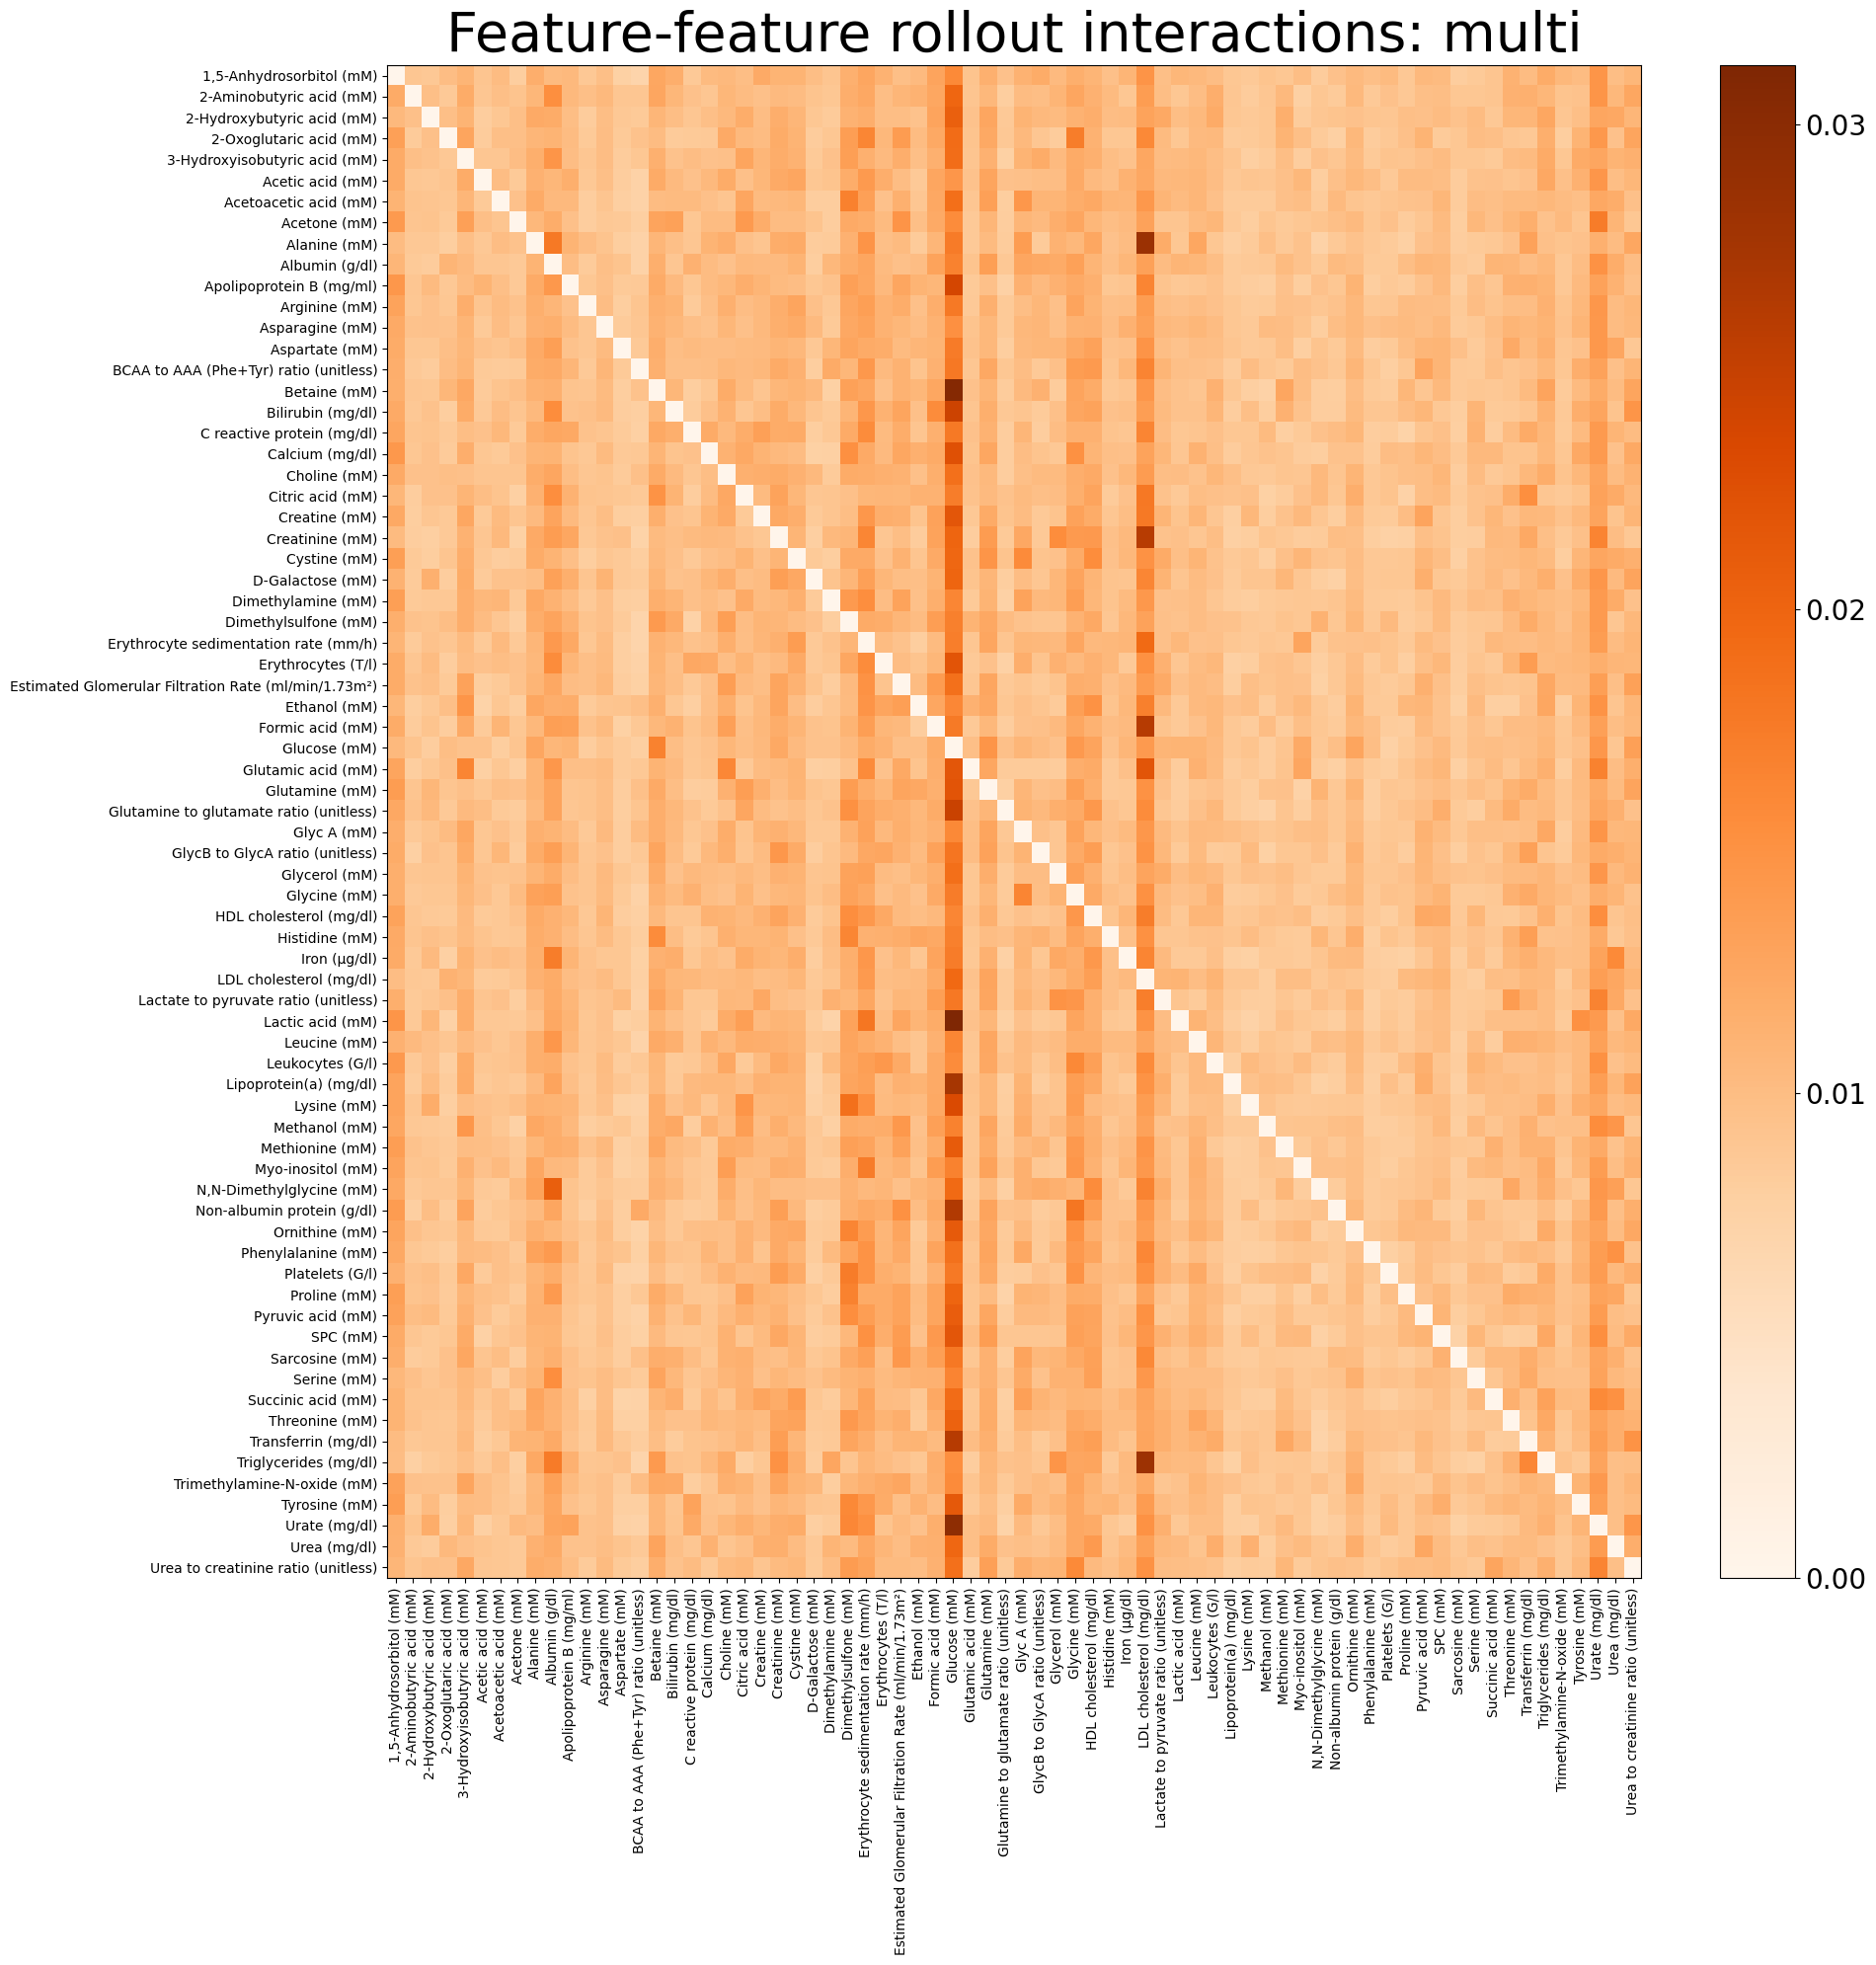

In [10]:
A = interactions.copy()

remove_diag=True

if remove_diag:
    np.fill_diagonal(A, 0)
    
VMIN = np.min(A) + 1e-8
VMAX = np.max(A)
plt.figure(figsize=(20, 20))
im = plt.imshow(A, aspect='auto', cmap='Oranges', 
                #norm=LogNorm(vmin=VMIN, vmax=VMAX)
               )

plt.title(f"Feature-feature rollout interactions: multi", fontsize=40, pad=10)

# ticks = np.linspace(VMIN, VMAX, 9)
# cbar = plt.colorbar(im, ticks=ticks)
# cbar.set_ticklabels([f"{t:.2f}" for t in ticks], fontsize=20)

ticks = [0, 0.01, 0.02, 0.03, 0.04]
cbar = plt.colorbar(im, ticks=ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks], fontsize=20)

plt.xticks(
    ticks=np.arange(len(feature_names)),
    labels=feature_names,
    rotation=90,
    fontsize=10
)

plt.yticks(
    ticks=np.arange(len(feature_names)),
    labels=feature_names,
    fontsize=10
)
plt.tight_layout()
plt.savefig(f"FiguresPaper/attention_rollout/interactions_all_multi.pdf", bbox_inches="tight")
plt.show()

#### Single output models